# Housing Price Analysis

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Renitia\\OneDrive\\Desktop\\Porto\\Portfolio\\data\\AmesHousing.csv')

## About Dataset

this data has unique size with 2930 rows and 82 column

In [34]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [36]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [37]:
df.shape

(2930, 82)

In [38]:
df.isnull().sum().sort_values(ascending=False).head(20)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

📊 Data Insight – Ames Housing Dataset (Missing Values Handling)

The dataset contains a mix of numerical and categorical features, with several columns having missing values. However, these missing values are not always true data errors.

🧠 Key Insight 1: Missing values often represent meaningful information

In the Ames Housing dataset, many missing values in categorical features actually indicate the absence of a property feature, rather than unknown data.

For example:

PoolQC missing → the house likely does not have a pool
Fence missing → the house likely does not have a fence
FireplaceQu missing → the house likely does not have a fireplace

Therefore, treating these as "None" is more appropriate than deleting or imputing with mode.

🏠 Key Insight 2: Categorical missing values can be standardized

All categorical columns with missing values can be safely encoded using a unified strategy:

Replace missing values with "None"
This preserves information about the absence of a feature

This approach prevents data loss and keeps feature meaning intact.

📉 Key Insight 3: Numerical missing values require a different approach

For numerical features, missing values are typically less meaningful and can be handled using:

Median imputation (preferred due to robustness against outliers)
⚙️ Key Insight 4: Automation improves consistency

Given the dataset size (82 columns), manual handling is inefficient. A systematic approach is preferred:

Categorical → fill with "None"
Numerical → fill with median

This ensures consistency, scalability, and reduces human error.

🚀 Overall Conclusion

Missing values in Ames Housing are not simply data problems, but often represent latent information about house features. Proper handling of these missing values is crucial because it directly impacts feature interpretation and model performance in predictive tasks such as house price estimation.

## HANDLING Missing Data

In [39]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns
num_cols = df.select_dtypes(exclude=["object", "string"]).columns

df[cat_cols] = df[cat_cols].fillna("None")
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## Exploratory Data Analysis (EDA)

First, we analyze the correlation between each feature and SalePrice, then rank the features from the highest to the lowest correlation.

In [40]:
df[num_cols].corr()["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647812
Garage Area        0.640381
Total Bsmt SF      0.632164
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.508882
Mas Vnr Area       0.502196
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432862
Lot Frontage       0.340256
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.275823
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182895
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.006018
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035817
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

### 1. Overall Quality vs SalePrice

Overall Qual is an ordinal feature that represents the overall material and finish quality of a house. The rating ranges from 1 to 10, where higher values indicate better quality.

1 = Very Poor
2 = Poor
3 = Fair
4 = Below Average
5 = Average
6 = Above Average
7 = Good
8 = Very Good
9 = Excellent
10 = Very Excellent

At first glance, there appears to be a positive relationship between Overall Qual and SalePrice, with higher-quality houses generally selling for higher prices.

In [41]:
df["Overall Qual"].unique()

array([ 6,  5,  7,  8,  9,  4,  3,  2, 10,  1])

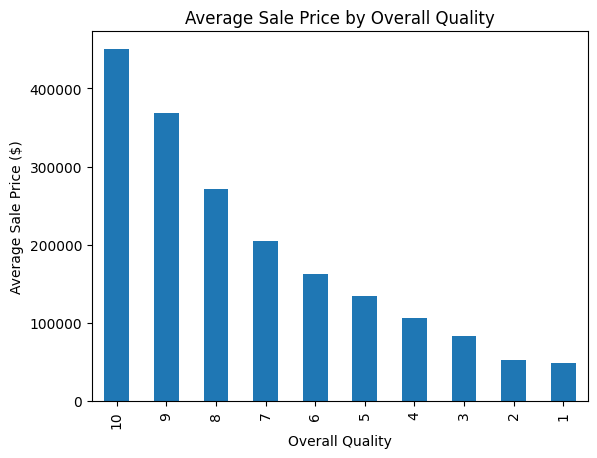

In [42]:
sale_price_by_overall_qual = (
    df.groupby("Overall Qual")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

ax = sale_price_by_overall_qual.plot(kind="bar")
plt.title("Average Sale Price by Overall Quality")
plt.ylabel("Average Sale Price ($)")
plt.xlabel("Overall Quality")
plt.show()

Based on both the correlation analysis and the average sale price by quality rating, Overall Qual appears to be one of the most influential features associated with house prices.

### 2. Gr Liv Area vs SalePrice

Based on simple intuition, we would expect houses with larger Gr Liv Area values to have higher sale prices.

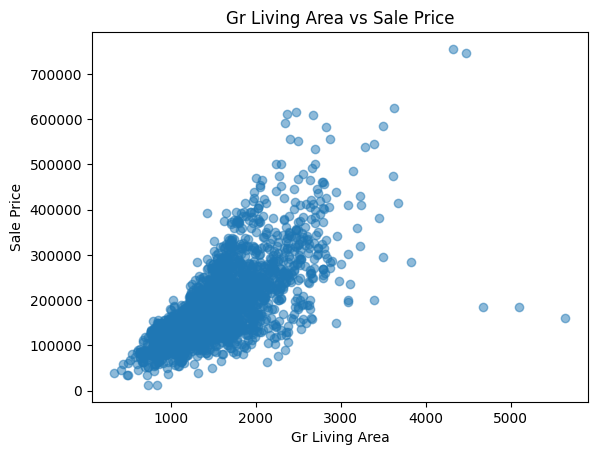

In [43]:
plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.5)
plt.xlabel("Gr Living Area")
plt.ylabel("Sale Price")
plt.title("Gr Living Area vs Sale Price")
plt.show()

As expected, there is a positive relationship between Gr Liv Area and SalePrice, with larger homes generally commanding higher prices. However, the scatter plot also reveals several outliers that deviate from this pattern and may require further investigation.

While larger living areas are generally associated with higher sale prices, several extreme outliers were identified. These properties have unusually large living areas but relatively low sale prices, suggesting that other factors such as neighborhood, condition, or property characteristics may influence the final selling price.

### 3. Neighborhood Vs SalePrice

In [44]:
df["Neighborhood"].unique()

<StringArray>
[  'NAmes', 'Gilbert', 'StoneBr',  'NWAmes', 'Somerst',  'BrDale', 'NPkVill',
 'NridgHt', 'Blmngtn', 'NoRidge', 'SawyerW',  'Sawyer',  'Greens', 'BrkSide',
 'OldTown',  'IDOTRR', 'ClearCr',   'SWISU', 'Edwards', 'CollgCr', 'Crawfor',
 'Blueste', 'Mitchel',  'Timber', 'MeadowV', 'Veenker', 'GrnHill', 'Landmrk']
Length: 28, dtype: str

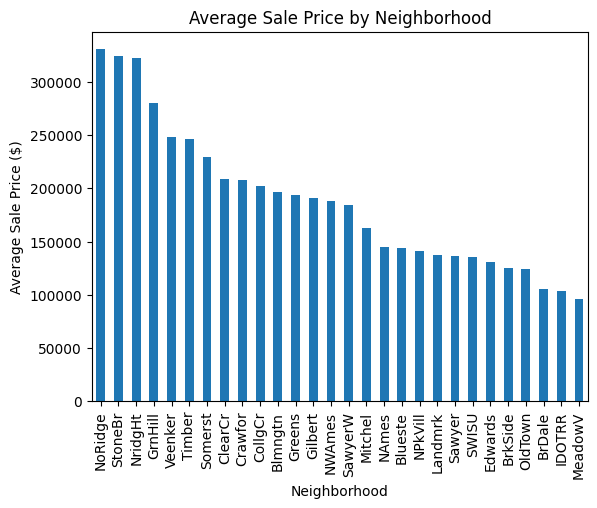

In [45]:
sale_price_by_Neighborhood = (
    df.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

ax = sale_price_by_Neighborhood.plot(kind="bar")
plt.title("Average Sale Price by Neighborhood")
plt.ylabel("Average Sale Price ($)")
plt.xlabel("Neighborhood")
plt.show()

In [46]:
df.nlargest(
    10,
    "Gr Liv Area"
)[
    ["Gr Liv Area", "SalePrice", "Neighborhood", "Overall Qual"]
]

,Gr Liv Area,SalePrice,Neighborhood,Overall Qual
1498,5642,160000,Edwards,10
2180,5095,183850,Edwards,10
2181,4676,184750,Edwards,10
1760,4476,745000,NoRidge,10
1767,4316,755000,NoRidge,10
1497,3820,284700,Edwards,5
2737,3672,415000,Edwards,6
2445,3627,625000,NoRidge,10
2666,3608,475000,OldTown,10
2450,3500,584500,NoRidge,9


In [47]:
df[df["Gr Liv Area"] > 5000][
    ["Gr Liv Area", "SalePrice", "Neighborhood", "Overall Qual"]
]

,Gr Liv Area,SalePrice,Neighborhood,Overall Qual
1498,5642,160000,Edwards,10
2180,5095,183850,Edwards,10


The outliers are primarily located in Edwards, a relatively lower-priced neighborhood. This indicates that neighborhood can have a significant impact on house prices, even for homes with exceptionally large living areas.

### 4. House Age

Based on simple intuition, we would expect newer built house values to have higher sale prices.

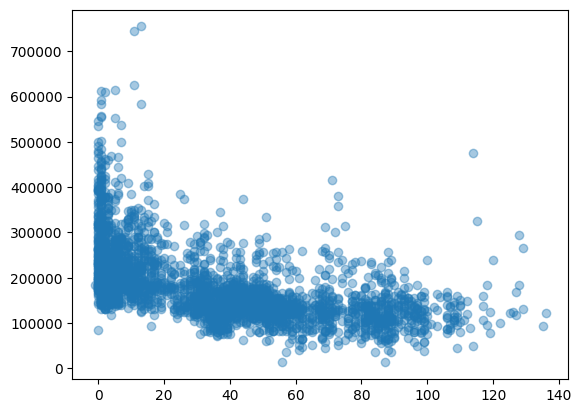

In [48]:
df["HouseAge"] = df["Yr Sold"] - df["Year Built"]

plt.scatter(df["HouseAge"], df["SalePrice"], alpha=0.4)

The scatter plot suggests that newer houses generally command higher sale prices. However, the relationship is weaker than those observed for Overall Qual and Gr Liv Area.

## Key Findings

1. Overall Qual is the strongest feature associated with SalePrice.

2. Larger living areas generally lead to higher sale prices.

3. Several large-house outliers were identified and traced to Edwards, a relatively lower-priced neighborhood.

4. Neighborhood plays a significant role in determining house prices, with NoRidge having the highest average sale price.

5. House age appears to influence sale prices, although its impact is weaker than quality and living area.